In [1]:
import sys
sys.path.append("../")

from src.data_loader import DataLoader

loader = DataLoader(data_dir="../data/")

x_train, y_train, x_test = loader.load_all()

print(f"x_train : {x_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape}")

[WARNING] x_train contient 839634 valeurs manquantes.
[WARNING] x_test contient 875392 valeurs manquantes.
x_train : (636313, 111)
y_train : (636313, 2)
x_test  : (635397, 111)


DESCRIPTION DU DATASET
  Lignes totales        :    636,313
  Colonnes totales      :        111
  Stocks uniques        :        318
  Jours uniques         :      2,117
  Colonnes volatilité   :         54
  Colonnes return dir.  :         54

VALEURS MANQUANTES
  Lignes avec au moins 1 NaN : 99,701 (15.7%)
  NaN moyen par ligne        : 0.66
  Max NaN sur une ligne      : 53


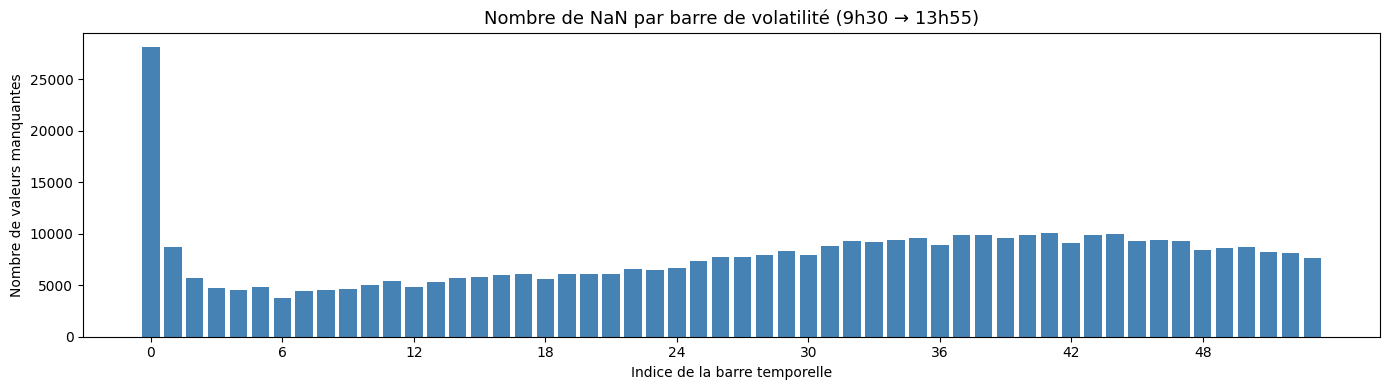


DISTRIBUTION DE LA TARGET (vol 14h-16h)
count    636313.000000
mean          0.183569
std           0.155562
min           0.000132
25%           0.098403
50%           0.141679
75%           0.214632
max           7.581517

  Skewness  : 5.014
  Kurtosis  : 59.902


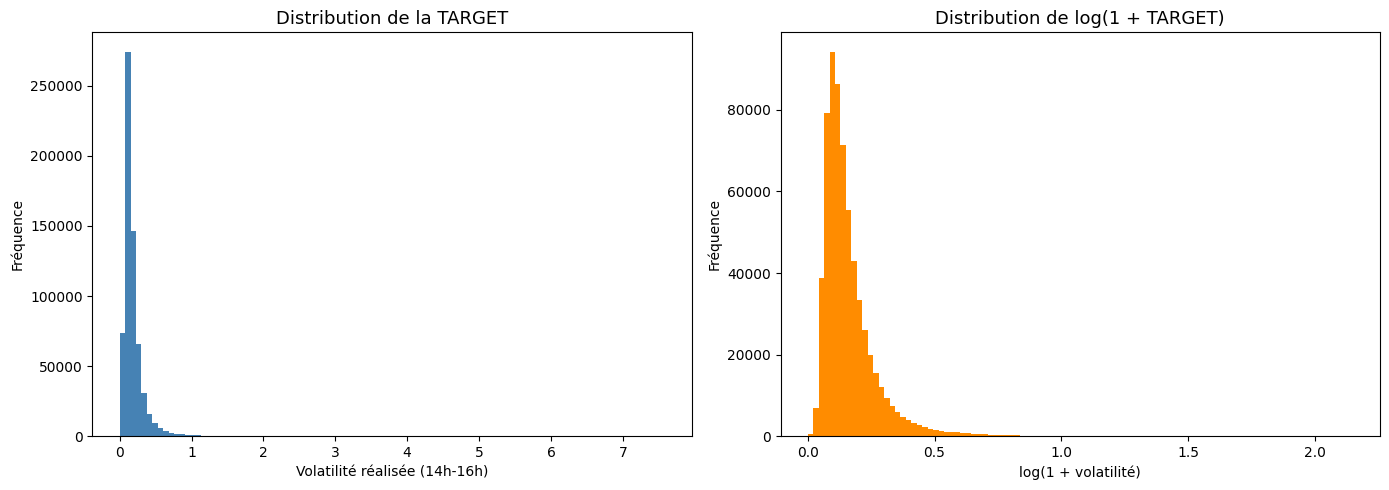


PERSISTANCE DE LA VOLATILITÉ
  Corrélation vol matin / TARGET : 0.8573


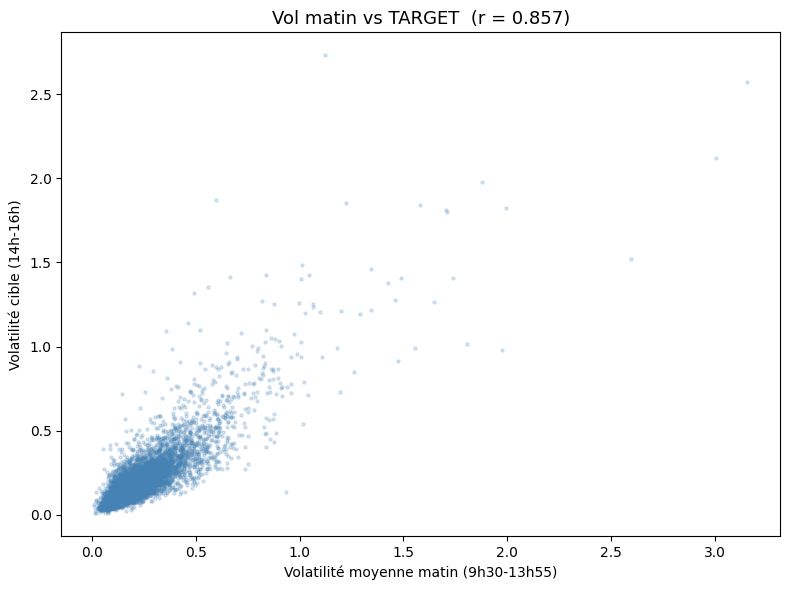

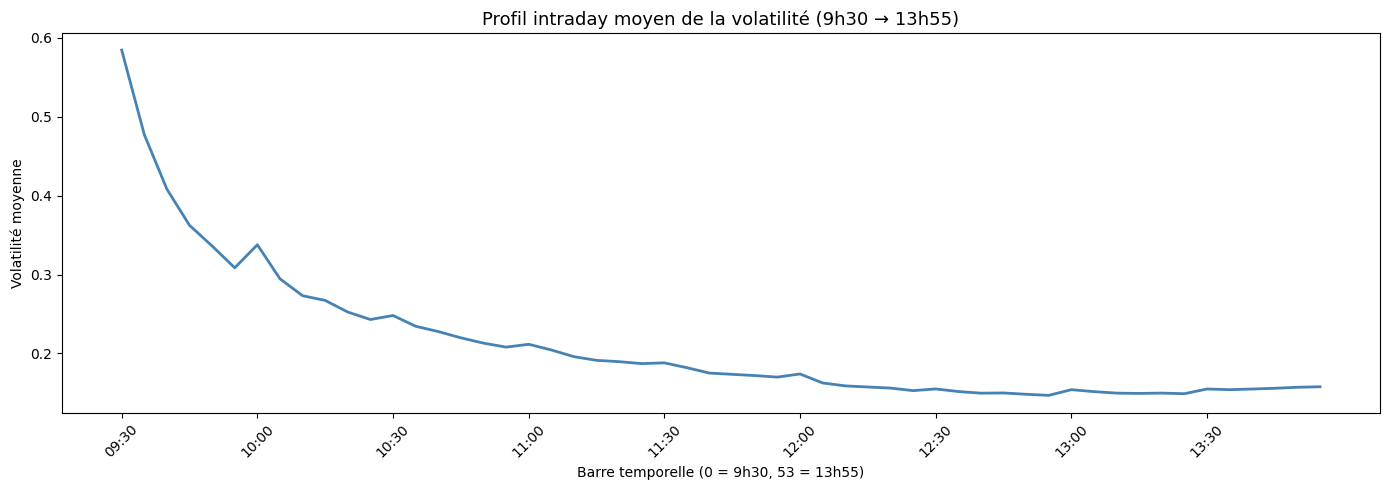

In [2]:
from src.eda_analyzer import EDAAnalyzer

eda = EDAAnalyzer(x_train, y_train, output_dir="../outputs/")
eda.run()

In [3]:
# NaN par barre temporelle
missing_per_col = x_train[eda.volatility_columns].isnull().sum()
print("5 premières barres:")
print(missing_per_col.head().to_string())
print("\n5 dernières barres:")
print(missing_per_col.tail().to_string())

# Profil intraday
mean_by_bar = x_train[eda.volatility_columns].mean()
print("\nVol moyenne toutes les 6 barres:")
print(mean_by_bar.iloc[::6].to_string())

5 premières barres:
volatility 09:30:00    28091
volatility 09:35:00     8755
volatility 09:40:00     5657
volatility 09:45:00     4756
volatility 09:50:00     4536

5 dernières barres:
volatility 13:35:00    8606
volatility 13:40:00    8746
volatility 13:45:00    8230
volatility 13:50:00    8166
volatility 13:55:00    7671

Vol moyenne toutes les 6 barres:
volatility 09:30:00    0.584382
volatility 10:00:00    0.337733
volatility 10:30:00    0.248104
volatility 11:00:00    0.211613
volatility 11:30:00    0.188078
volatility 12:00:00    0.173996
volatility 12:30:00    0.155027
volatility 13:00:00    0.154092
volatility 13:30:00    0.154943


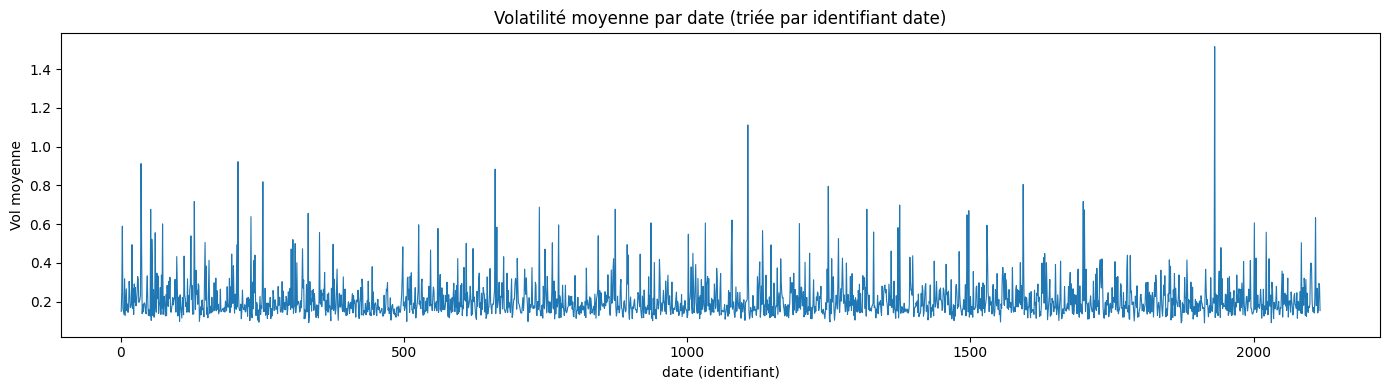

In [4]:
# Est-ce que la volatilité moyenne varie dans le temps
# de manière cohérente avec un ordre chronologique réel ?

import matplotlib.pyplot as plt

mean_vol_by_date = (
    x_train[eda.volatility_columns]
    .mean(axis=1)
    .groupby(x_train["date"])
    .mean()
    .sort_index()
)

plt.figure(figsize=(14, 4))
plt.plot(mean_vol_by_date.index, mean_vol_by_date.values, linewidth=0.8)
plt.title("Volatilité moyenne par date (triée par identifiant date)")
plt.xlabel("date (identifiant)")
plt.ylabel("Vol moyenne")
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

target = y_train["TARGET"]

p995 = np.percentile(target, 99.5)
p999 = np.percentile(target, 99.9)
p100 = target.max()

print(f"99.5e percentile : {p995:.4f}")
print(f"99.9e percentile : {p999:.4f}")
print(f"Maximum          : {p100:.4f}")
print(f"Valeurs > 99.5p  : {(target > p995).sum()}")
print(f"Valeurs > 99.9p  : {(target > p999).sum()}")

99.5e percentile : 1.0225
99.9e percentile : 1.5931
Maximum          : 7.5815
Valeurs > 99.5p  : 3182
Valeurs > 99.9p  : 637


In [6]:
from src.feature_engineer import FeatureEngineer

engineer = FeatureEngineer(x_train, x_test)
features_train, features_test = engineer.build()

print(f"Features train : {features_train.shape}")
print(f"Features test  : {features_test.shape}")
print(f"\nColonnes générées :")
print([c for c in features_train.columns if c != 'ID'])

Features train : (636313, 11)
Features test  : (635397, 11)

Colonnes générées :
['vol_mean', 'vol_mean_minus_median', 'vol_mean_recent', 'vol_last_bar', 'vol_linear_slope', 'vol_std', 'vol_min', 'vol_recent_over_mean', 'return_n_positive', 'return_n_negative']


In [7]:
import numpy as np

# Joindre les features avec la target pour analyser les corrélations
target = np.log(y_train["TARGET"])  # log-transform comme décidé

feature_cols = [c for c in features_train.columns if c != "ID"]

print("Corrélation de chaque feature avec log(TARGET) :")
print("=" * 50)

correlations = {}
for col in feature_cols:
    r = np.corrcoef(features_train[col], target)[0, 1]
    correlations[col] = r

# Tri par corrélation absolue décroissante
sorted_corr = sorted(
    correlations.items(),
    key=lambda x: abs(x[1]),
    reverse=True
)

for name, r in sorted_corr:
    print(f"  {name:<30} : {r:+.4f}")

Corrélation de chaque feature avec log(TARGET) :
  vol_mean                       : +0.7682
  vol_mean_recent                : +0.6777
  vol_std                        : +0.6533
  vol_min                        : +0.5621
  vol_last_bar                   : +0.5342
  vol_mean_minus_median          : +0.5191
  vol_linear_slope               : -0.4211
  return_n_negative              : +0.2116
  vol_recent_over_mean           : +0.1918
  return_n_positive              : +0.1490


In [8]:
import numpy as np

target = np.log(y_train["TARGET"])
feature_cols = [c for c in features_train.columns if c != "ID"]

print("Corrélation de chaque feature avec log(TARGET) :")
print("=" * 50)

correlations = {}
for col in feature_cols:
    r = np.corrcoef(features_train[col], target)[0, 1]
    correlations[col] = r

sorted_corr = sorted(
    correlations.items(),
    key=lambda x: abs(x[1]),
    reverse=True
)

for name, r in sorted_corr:
    print(f"  {name:<30} : {r:+.4f}")

Corrélation de chaque feature avec log(TARGET) :
  vol_mean                       : +0.7682
  vol_mean_recent                : +0.6777
  vol_std                        : +0.6533
  vol_min                        : +0.5621
  vol_last_bar                   : +0.5342
  vol_mean_minus_median          : +0.5191
  vol_linear_slope               : -0.4211
  return_n_negative              : +0.2116
  vol_recent_over_mean           : +0.1918
  return_n_positive              : +0.1490


In [9]:
engineer = FeatureEngineer(x_train, x_test)
features_train, features_test = engineer.build()
print(f"Shape final : {features_train.shape}")
print(f"Features    : {[c for c in features_train.columns if c != 'ID']}")

Shape final : (636313, 11)
Features    : ['vol_mean', 'vol_mean_minus_median', 'vol_mean_recent', 'vol_last_bar', 'vol_linear_slope', 'vol_std', 'vol_min', 'vol_recent_over_mean', 'return_n_positive', 'return_n_negative']


In [10]:
# Calculer le ratio gamma
p = 12         # features
n = 636_313    # observations
gamma = p / n

# Bord supérieur Marchenko-Pastur
sigma2 = 1.0   # features normalisées → variance unitaire
lambda_plus = sigma2 * (1 + np.sqrt(gamma))**2
lambda_minus = sigma2 * (1 - np.sqrt(gamma))**2

print(f"gamma        : {gamma:.6f}")
print(f"lambda_+     : {lambda_plus:.6f}")
print(f"lambda_-     : {lambda_minus:.6f}")

# Comparer aux valeurs propres empiriques
from sklearn.preprocessing import StandardScaler
import numpy as np

feature_cols = [c for c in features_train.columns if c != 'ID']
X = StandardScaler().fit_transform(features_train[feature_cols])
cov_matrix = np.cov(X.T)
eigenvalues = np.linalg.eigvalsh(cov_matrix)[::-1]

print("\nValeurs propres empiriques vs bord MP :")
for i, ev in enumerate(eigenvalues):
    flag = "SIGNAL" if ev > lambda_plus else "BRUIT"
    print(f"  PC{i+1:2d} : {ev:.4f}  → {flag}")

gamma        : 0.000019
lambda_+     : 1.008704
lambda_-     : 0.991334

Valeurs propres empiriques vs bord MP :
  PC 1 : 4.7474  → SIGNAL
  PC 2 : 1.6811  → SIGNAL
  PC 3 : 1.1637  → SIGNAL
  PC 4 : 0.9397  → BRUIT
  PC 5 : 0.5075  → BRUIT
  PC 6 : 0.4097  → BRUIT
  PC 7 : 0.2742  → BRUIT
  PC 8 : 0.1858  → BRUIT
  PC 9 : 0.0558  → BRUIT
  PC10 : 0.0350  → BRUIT


In [11]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau

feature_cols = [c for c in features_train.columns if c != "ID"]

# ----------------------------------------------------------------
# 1. Matrice de corrélation rankée globale (Spearman)
# ----------------------------------------------------------------
X = features_train[feature_cols].values
n_features = len(feature_cols)

spearman_matrix = np.zeros((n_features, n_features))
for i in range(n_features):
    for j in range(n_features):
        r, _ = spearmanr(X[:, i], X[:, j])
        spearman_matrix[i, j] = r

df_spearman_global = pd.DataFrame(
    spearman_matrix,
    index=feature_cols,
    columns=feature_cols
)

print("=" * 60)
print("MATRICE DE CORRÉLATION RANKÉE GLOBALE (Spearman)")
print("=" * 60)
print(df_spearman_global.round(3).to_string())

# ----------------------------------------------------------------
# 2. IC rankée (Kendall tau) de chaque feature vs log(TARGET)
# ----------------------------------------------------------------
target_log = np.log(y_train["TARGET"].values)

print("\n" + "=" * 60)
print("IC RANKÉE (Kendall tau) vs log(TARGET)")
print("=" * 60)

kendall_ics = {}
for col in feature_cols:
    tau, pval = kendalltau(features_train[col].values, target_log)
    kendall_ics[col] = (tau, pval)

sorted_kendall = sorted(
    kendall_ics.items(),
    key=lambda x: abs(x[1][0]),
    reverse=True
)

print(f"  {'Feature':<30} {'Kendall tau':>12} {'p-value':>12} {'Signal':>8}")
print(f"  {'-'*30} {'-'*12} {'-'*12} {'-'*8}")
for name, (tau, pval) in sorted_kendall:
    signal = "OUI" if pval < 0.05 else "NON"
    print(f"  {name:<30} {tau:>+12.4f} {pval:>12.2e} {signal:>8}")

# ----------------------------------------------------------------
# 3. Corrélation cross-sectionnelle rankée (Spearman par date)
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("IC CROSS-SECTIONNEL MOYEN (Spearman par date)")
print("=" * 60)

x_with_meta = x_train[["ID", "date"]].copy()
x_with_meta = x_with_meta.reset_index(drop=True)
features_with_date = features_train.copy()
features_with_date["date"] = x_with_meta["date"].values
features_with_date["target_log"] = target_log

dates = features_with_date["date"].unique()
cross_section_ics = {col: [] for col in feature_cols}

for date in dates:
    mask = features_with_date["date"] == date
    subset = features_with_date[mask]

    # Minimum 10 stocks pour calculer une corrélation stable
    if len(subset) < 10:
        continue

    for col in feature_cols:
        r, _ = spearmanr(subset[col].values, subset["target_log"].values)
        if not np.isnan(r):
            cross_section_ics[col].append(r)

print(f"  {'Feature':<30} {'IC moyen':>10} {'IC std':>10} {'t-stat':>10}")
print(f"  {'-'*30} {'-'*10} {'-'*10} {'-'*10}")

cross_section_results = {}
for col in feature_cols:
    ics = np.array(cross_section_ics[col])
    ic_mean = ics.mean()
    ic_std  = ics.std()
    t_stat  = ic_mean / (ic_std / np.sqrt(len(ics))) if ic_std > 0 else 0
    cross_section_results[col] = (ic_mean, ic_std, t_stat)

sorted_cs = sorted(
    cross_section_results.items(),
    key=lambda x: abs(x[1][2]),
    reverse=True
)

for name, (ic_mean, ic_std, t_stat) in sorted_cs:
    print(f"  {name:<30} {ic_mean:>+10.4f} {ic_std:>10.4f} {t_stat:>+10.2f}")

MATRICE DE CORRÉLATION RANKÉE GLOBALE (Spearman)
                       vol_mean  vol_mean_minus_median  vol_mean_recent  vol_last_bar  vol_linear_slope  vol_std  vol_min  vol_recent_over_mean  return_n_positive  return_n_negative
vol_mean                  1.000                  0.644            0.792         0.543            -0.609    0.879    0.537                 0.078              0.226              0.267
vol_mean_minus_median     0.644                  1.000            0.425         0.278            -0.626    0.822    0.219                -0.109              0.036              0.042
vol_mean_recent           0.792                  0.425            1.000         0.673            -0.240    0.631    0.490                 0.625              0.196              0.256
vol_last_bar              0.543                  0.278            0.673         1.000            -0.175    0.418    0.383                 0.421              0.164              0.215
vol_linear_slope         -0.609          

In [ ]:
print(f"Shape final : {features_train.shape}")
print(f"Features    : {[c for c in features_train.columns if c != 'ID']}")